In [1]:
!pip install -q segmentation-models-pytorch albumentations torch torchvision opencv-python scikit-learn matplotlib


[notice] A new release of pip is available: 23.0.1 -> 26.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [1]:
import os, numpy as np, cv2, torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

c:\Users\Eugen\intro-to-neural-networks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda


In [6]:
# Пути и параметры
DATA_DIR = './tiff/'
ENCODER = 'resnet50'
INPUT_SIZE = 1500
BATCH_SIZE = 4
EPOCHS = 20
LR = 1e-4
THRESHOLD = 0.5

# Препроцессинг для ResNet50
preprocessing_fn = smp.encoders.get_preprocessing_fn(ENCODER, 'imagenet')

In [3]:
# Нормализация для ResNet50 (ImageNet stats)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_aug = A.Compose([
    A.RandomCrop(INPUT_SIZE, INPUT_SIZE),
    A.HorizontalFlip(), A.VerticalFlip(), A.RandomRotate90(),
    A.ColorJitter(brightness=0.2, contrast=0.2, p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),  # Нормализация ЗДЕСЬ
    ToTensorV2()  # Последним шагом!
], additional_targets={'mask': 'mask'})

val_aug = A.Compose([
    A.Resize(INPUT_SIZE, INPUT_SIZE),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),  # Нормализация ЗДЕСЬ
    ToTensorV2()
], additional_targets={'mask': 'mask'})

In [ ]:
class RoadsDataset(Dataset):
    def __init__(self, imgs, masks, aug=None):
        self.imgs, self.masks, self.aug = imgs, masks, aug
    
    def __len__(self): return len(self.imgs)
    
    def __getitem__(self, idx):
        # Загрузка изображения и маски (OpenCV: HWC)
        img = cv2.cvtColor(cv2.imread(self.imgs[idx]), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(self.masks[idx], cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)[..., None]  
        
        # Аугментации (Albumentations работает с numpy HWC)
        if self.aug:
            sample = self.aug(image=img, mask=mask)
            img = sample['image']   
            mask = sample['mask']  
        
        if isinstance(mask, np.ndarray):
            # Если маска ещё в numpy
            if mask.ndim == 3 and mask.shape[-1] == 1:
                mask = mask.transpose(2, 0, 1) 
            elif mask.ndim == 2:
                mask = mask[None, ...]           
        else:
            # Если маска уже torch tensor
            if mask.ndim == 3 and mask.shape[-1] == 1:
                mask = mask.permute(2, 0, 1)    
            elif mask.ndim == 2:
                mask = mask.unsqueeze(0)          
        
        return img, mask  

In [7]:
def load_paths(split):
    imgs = sorted([os.path.join(DATA_DIR, split, f) for f in os.listdir(os.path.join(DATA_DIR, split)) if f.endswith('.tiff')])
    masks = sorted([os.path.join(DATA_DIR, split+'_labels', f) for f in os.listdir(os.path.join(DATA_DIR, split+'_labels')) if f.endswith('.tif')])
    return imgs, masks

train_i, train_m = load_paths('train')
val_i, val_m = load_paths('val')
test_i, test_m = load_paths('test')

train_ds = RoadsDataset(train_i, train_m, train_aug)
val_ds = RoadsDataset(val_i, val_m, val_aug)
test_ds = RoadsDataset(test_i, test_m, val_aug)

train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, 1, shuffle=False)

In [ ]:
# Модель U-Net + ResNet50
model = smp.Unet(encoder_name=ENCODER, encoder_weights='imagenet', classes=1, activation=None).to(DEVICE)

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)  
        pred, target = pred.view(-1), target.view(-1)
        intersection = (pred * target).sum()
        dice = (2. * intersection + self.smooth) / (pred.sum() + target.sum() + self.smooth)
        return 1 - dice

class TverskyLoss(nn.Module):
    def __init__(self, smooth=1.0, alpha=0.7, beta=0.3):
        super().__init__()
        self.smooth, self.alpha, self.beta = smooth, alpha, beta
    def forward(self, pred, target):
        pred = torch.sigmoid(pred) 
        pred, target = pred.view(-1), target.view(-1)
        intersection = (pred * target).sum()
        fp = ((1 - target) * pred).sum()
        fn = (target * (1 - pred)).sum()
        tversky = (intersection + self.smooth) / (intersection + self.alpha*fp + self.beta*fn + self.smooth)
        return 1 - tversky

class CombinedLoss(nn.Module):
    def __init__(self, bce_weight=0.4, dice_weight=0.3, tversky_weight=0.3):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()
        self.tversky = TverskyLoss()
        self.w_bce, self.w_dice, self.w_tversky = bce_weight, dice_weight, tversky_weight
    
    def forward(self, pred, target):
        return (self.w_bce * self.bce(pred, target) + 
                self.w_dice * self.dice(pred, target) +
                self.w_tversky * self.tversky(pred, target))

# Инициализация
criterion = CombinedLoss(bce_weight=0.4, dice_weight=0.3, tversky_weight=0.3).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, 
    max_lr=5e-4, 
    epochs=EPOCHS, 
    steps_per_epoch=len(train_loader),
    pct_start=0.1,  
    anneal_strategy='cos'
)


def iou_score(pred_prob, target, th=0.5):
    """pred_prob: после sigmoid, значения [0,1]"""
    pred_bin = (pred_prob > th).float()
    target_bin = (target > 0.5).float()
    inter = (pred_bin * target_bin).sum()
    union = pred_bin.sum() + target_bin.sum() - inter
    return (inter + 1e-7) / (union + 1e-7)

def dice_score(pred, target, th=THRESHOLD):
    pred_b = (pred > th).float()
    inter = (pred_b * target).sum()
    return (2*inter + 1e-7) / (pred_b.sum() + target.sum() + 1e-7)

def pixel_acc(pred, target, th=THRESHOLD):
    return ((pred > th).float() == target).float().mean()

In [9]:
if torch.cuda.device_count() > 1:
    print(f"Используем {torch.cuda.device_count()} GPU!")
    model = torch.nn.DataParallel(model)

In [10]:
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

history = {'train_loss': [], 'val_loss': [], 'val_iou': []}
best_iou = 0

for epoch in range(EPOCHS):
    model.train()
    t_loss = 0
    
    for imgs, masks in tqdm(train_loader, desc=f'Epoch {epoch+1}'):
        imgs, masks = imgs.to(DEVICE), (masks > 0.5).float().to(DEVICE)
        
        optimizer.zero_grad(set_to_none=True)
        with autocast():
            logits = model(imgs)
            loss = criterion(logits, masks)
            
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        
        t_loss += loss.item()
    
    # Validation
    model.eval()
    v_loss, v_iou = 0, 0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), (masks > 0.5).float().to(DEVICE)
            with autocast():
                logits = model(imgs)
                loss = criterion(logits, masks)
                v_loss += loss.item()
            
            preds = torch.sigmoid(logits)
            v_iou += iou_score(preds, masks).item()
            
    n = len(val_loader)
    history['train_loss'].append(t_loss/len(train_loader))
    history['val_loss'].append(v_loss/n)
    history['val_iou'].append(v_iou/n)
    
    print(f'Epoch {epoch+1}: TrainLoss={t_loss/len(train_loader):.4f} | '
          f'ValLoss={v_loss/n:.4f} | IoU={v_iou/n:.4f}')
    
    if v_iou/n > best_iou:
        best_iou = v_iou/n
        torch.save(model.state_dict(), 'best_model.pth')
        print(f'✓ Best IoU: {best_iou:.4f}')

Epoch 1: 100%|██████████| 277/277 [06:13<00:00,  1.35s/it]


Epoch 1: TrainLoss=0.7215 | ValLoss=0.4853 | IoU=0.5219
✓ Best IoU: 0.5219


Epoch 2: 100%|██████████| 277/277 [06:11<00:00,  1.34s/it]


Epoch 2: TrainLoss=0.3704 | ValLoss=0.2306 | IoU=0.5734
✓ Best IoU: 0.5734


Epoch 3: 100%|██████████| 277/277 [06:13<00:00,  1.35s/it]


...

Epoch 18: TrainLoss=0.2058 | ValLoss=0.1816 | IoU=0.6371


Epoch 19: 100%|██████████| 277/277 [06:14<00:00,  1.35s/it]


Epoch 19: TrainLoss=0.2033 | ValLoss=0.1796 | IoU=0.6405


Epoch 20: 100%|██████████| 277/277 [06:13<00:00,  1.35s/it]


Epoch 20: TrainLoss=0.2049 | ValLoss=0.1793 | IoU=0.6426


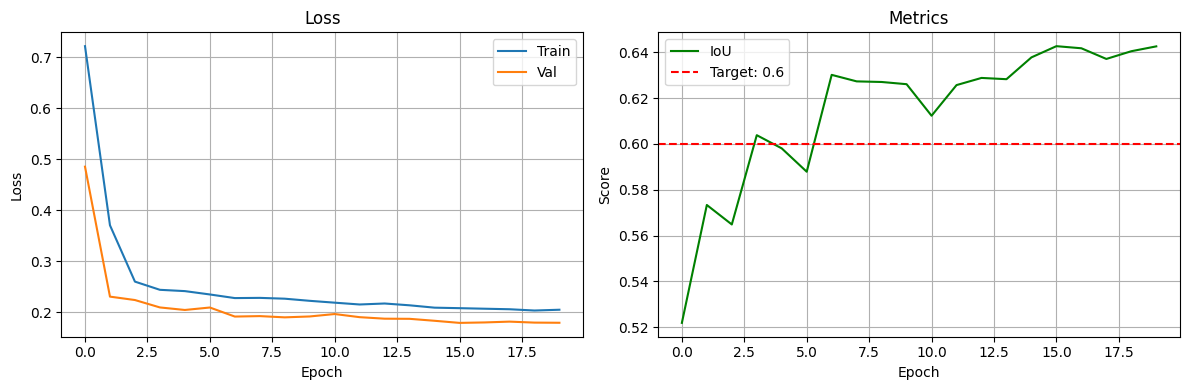

In [12]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['val_loss'], label='Val')
plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid()

plt.subplot(1, 2, 2)
plt.plot(history['val_iou'], color='green', label='IoU')
plt.axhline(0.6, color='red', linestyle='--', label='Target: 0.6')
plt.title('Metrics'); plt.xlabel('Epoch'); plt.ylabel('Score'); plt.legend(); plt.grid()
plt.tight_layout(); plt.savefig('training_plots.png', dpi=300); plt.show()

In [11]:
# Загрузка лучшей модели
model.load_state_dict(torch.load('best_model1500.pth', map_location=DEVICE))
model.eval()

# Оценка на тесте
test_iou, test_dice, test_acc = [], [], []
with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc='Testing'):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        out = model(imgs)
        test_iou.append(iou_score(out, masks).item())
        test_dice.append(dice_score(out, masks).item())
        test_acc.append(pixel_acc(out, masks).item())

print(f"\nTEST RESULTS:")
print(f"Pixel Accuracy: {np.mean(test_acc):.4f}")
print(f"IoU: {np.mean(test_iou):.4f}")
print(f"Dice: {np.mean(test_dice):.4f}")  

Testing: 100%|██████████| 49/49 [00:10<00:00,  4.60it/s]


TEST RESULTS:
Pixel Accuracy: 0.9810
IoU: 0.6426
Dice: 0.7793


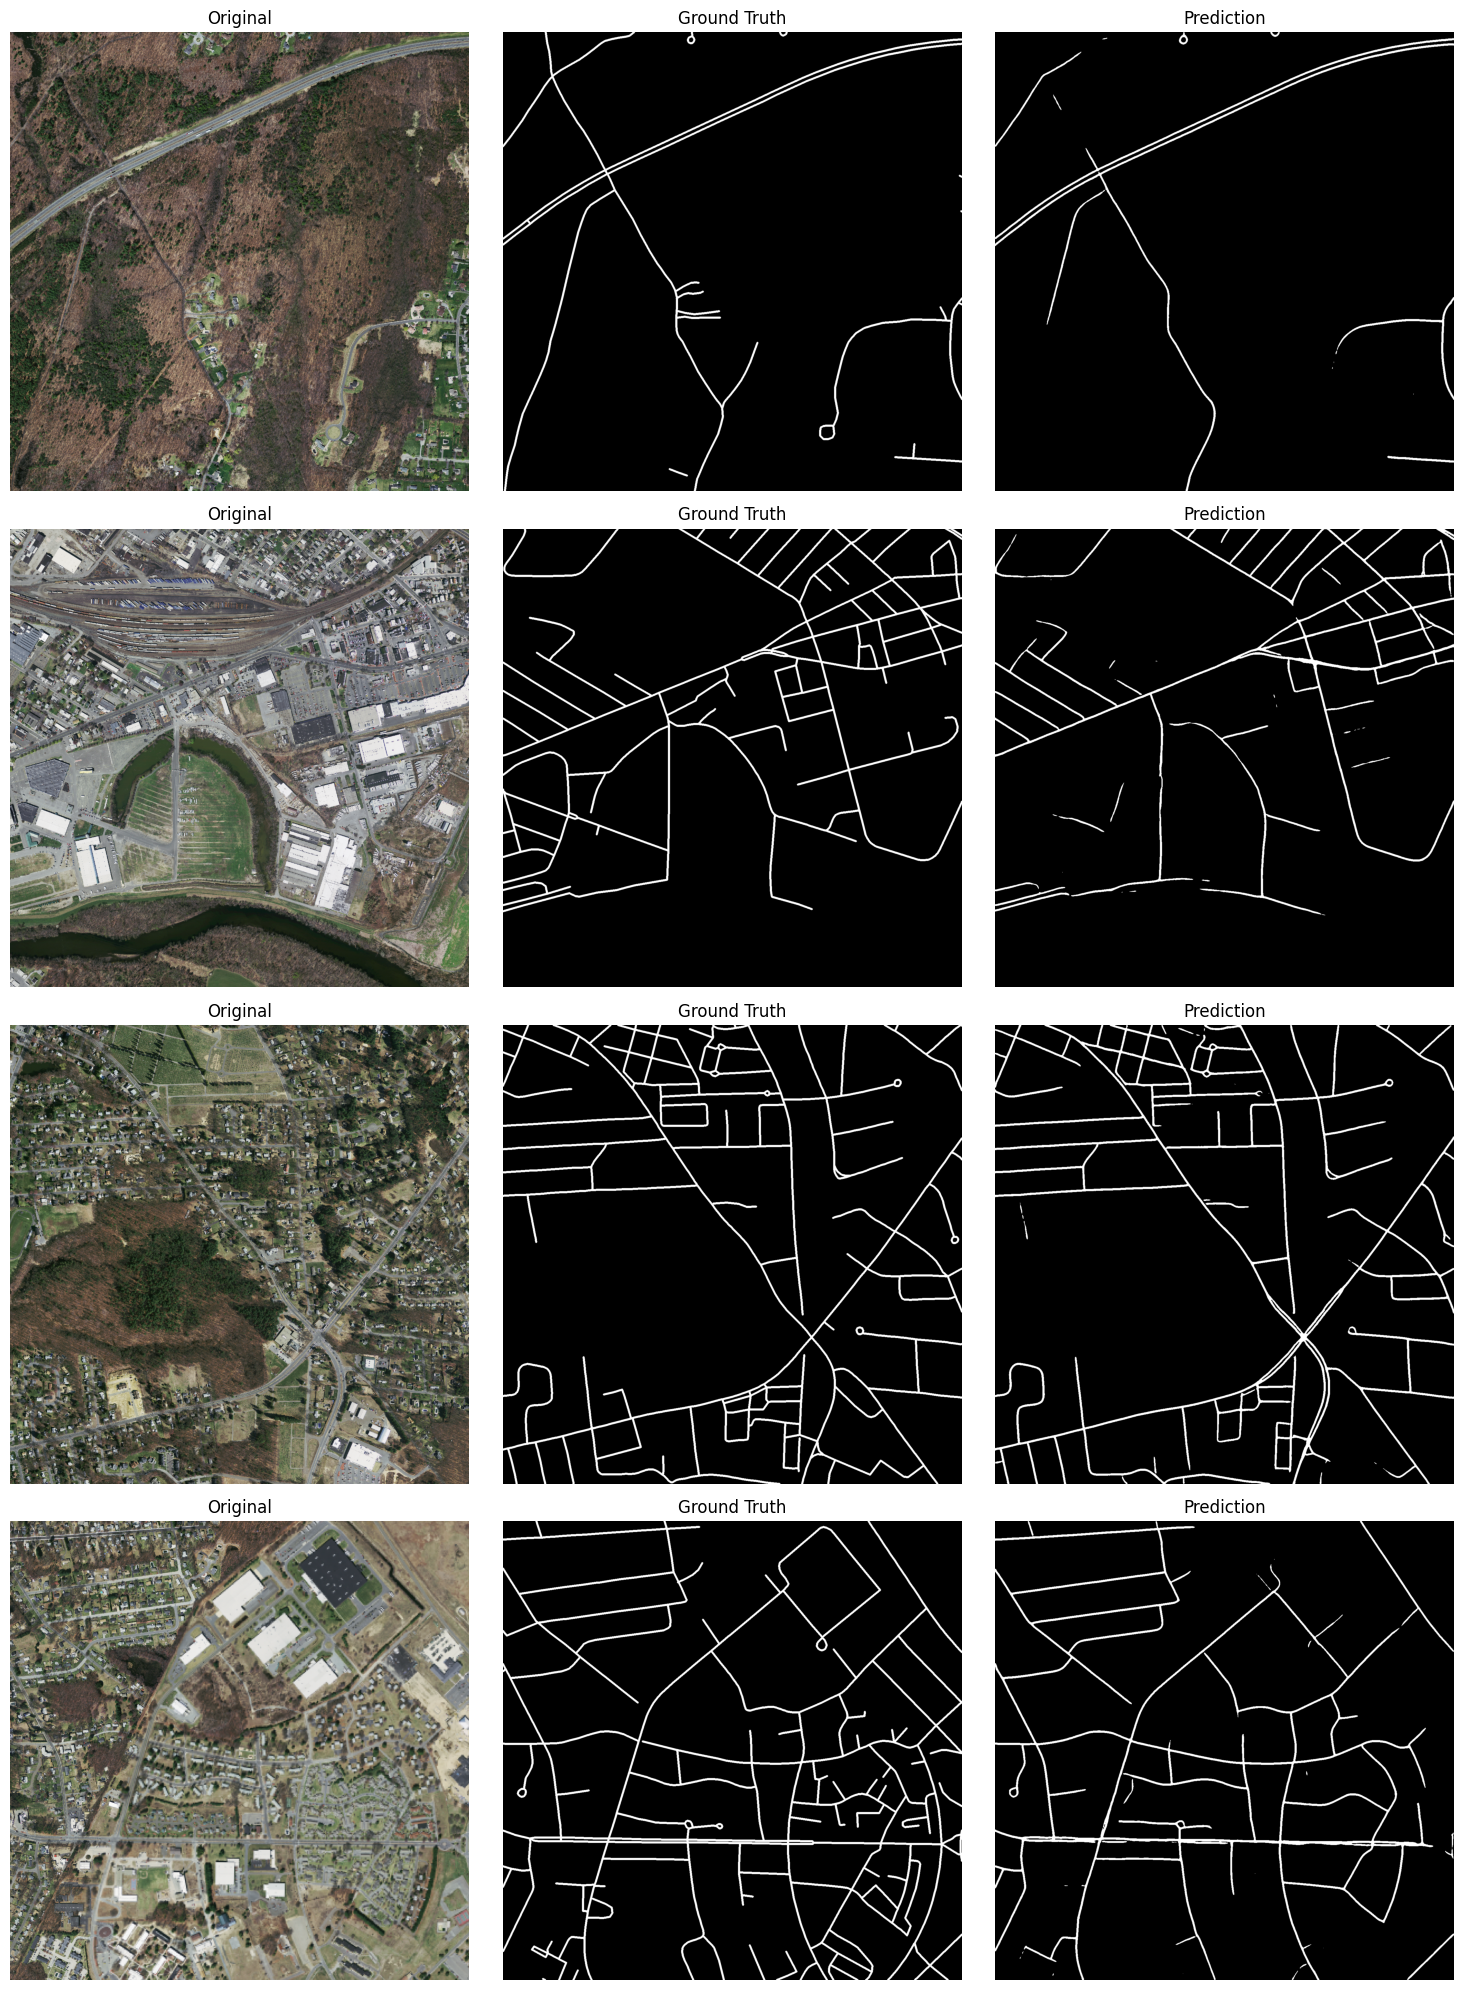

In [12]:
def visualize(model, img_path, mask_path, n=4):
    model.eval()
    fig, ax = plt.subplots(n, 3, figsize=(15, 5*n))
    
    for i, (img_p, mask_p) in enumerate(zip(test_i[:n], test_m[:n])):
        img = cv2.cvtColor(cv2.imread(img_p), cv2.COLOR_BGR2RGB)
        mask = (cv2.imread(mask_p, 0) > 127).astype(np.float32)
        
        # Prep
        aug = val_aug(image=img, mask=mask[...,None])
        img_t = aug['image'].unsqueeze(0).to(DEVICE)
        
        # Predict
        with torch.no_grad():
            pred = (model(img_t) > THRESHOLD).squeeze().cpu().numpy()
        
        # Show
        ax[i,0].imshow(img); ax[i,0].set_title('Original'); ax[i,0].axis('off')
        ax[i,1].imshow(mask, cmap='gray'); ax[i,1].set_title('Ground Truth'); ax[i,1].axis('off')
        ax[i,2].imshow(pred, cmap='gray'); ax[i,2].set_title(f'Prediction'); ax[i,2].axis('off')
    
    plt.tight_layout(); plt.savefig('results.png', dpi=300); plt.show()

visualize(model, test_i, test_m, n=4)